In [1]:
import sys
import importlib
import warnings
import random
from collections import defaultdict
import pickle
import os
import re
import os
import torchaudio


import torch
from tqdm import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sys.path.append("A:/Masters/Thesis/Dr. Mohsen Rashwan/projects/")

from stt_benchmarking.utils import helpers, text_processing, ensemble_analysis, metrics as mt, validate
from stt_benchmarking.etl import load_data
from stt_benchmarking.models.speech_to_text.arabic import ensemble, rover
from stt_benchmarking.models.llms import reinforcer


warnings.filterwarnings('ignore')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pd.set_option("display.max_colwidth", None)
random.seed(42)

print(device)

e:\Masters\Thesis\Dr. Mohsen Rashwan\projects\.venv\lib\site-packages\torch\backends\__init__.py:46: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:85.)
  self.setter(val)


cuda


In [3]:
egy_original_datapath = "../../data/original/Egy_Coll_5hrs/"
saudi_original_datapath = "../../data/original/Saudi_Coll_5hrs/"
egy_records = load_data.load_audio_transcripts(data_dir=egy_original_datapath, sep=" ", substitute=True)
saudi_records = load_data.load_audio_transcripts(data_dir=saudi_original_datapath, sep="|", substitute=True)
for rec in egy_records:
    rec["country_key"] = "Egypt"

# Add country_key to Saudi records
for rec in saudi_records:
    rec["country_key"] = "Saudi"

all_records = egy_records + saudi_records
filtered_records = [
    record for record in all_records
    if record['audio_duration'] < 30
]
len(all_records)
len(filtered_records)

RuntimeError: Could not load libtorchcodec. Likely causes:
          1. FFmpeg is not properly installed in your environment. We support
             versions 4, 5, 6 and 7.
          2. The PyTorch version (2.9.0+cu128) is not compatible with
             this version of TorchCodec. Refer to the version compatibility
             table:
             https://github.com/pytorch/torchcodec?tab=readme-ov-file#installing-torchcodec.
          3. Another runtime dependency; see exceptions below.
        The following exceptions were raised as we tried to load libtorchcodec:
        
[start of libtorchcodec loading traceback]
FFmpeg version 8: Could not load this library: E:\Masters\Thesis\Dr. Mohsen Rashwan\projects\.venv\Lib\site-packages\torchcodec\libtorchcodec_core8.dll
FFmpeg version 7: Could not load this library: E:\Masters\Thesis\Dr. Mohsen Rashwan\projects\.venv\Lib\site-packages\torchcodec\libtorchcodec_core7.dll
FFmpeg version 6: Could not load this library: E:\Masters\Thesis\Dr.

In [ ]:
bad_ids = ['../data/original/Egy_Coll_5hrs/waves\\AbdulHakeem-AbdulNasser-338-0873.wav',
 '../data/original/Egy_Coll_5hrs/waves\\AbdulHakeem-AbdulNasser-338-0885.wav',
 '../data/original/Egy_Coll_5hrs/waves\\AbdulHakeem-AbdulNasser-338-0898.wav',
 '../data/original/Egy_Coll_5hrs/waves\\AbdulHakeem-AbdulNasser-338-0980.wav',
 '../data/original/Egy_Coll_5hrs/waves\\AbdulHakeem-AbdulNasser-338-0667.wav',
 '../data/original/Egy_Coll_5hrs/waves\\AbdulHakeem-AbdulNasser-338-0681.wav',
 '../data/original/Egy_Coll_5hrs/waves\\AbdulHakeem-AbdulNasser-338-0714.wav',
 '../data/original/Egy_Coll_5hrs/waves\\AbdulHakeem-AbdulNasser-338-0687.wav',
 '../data/original/Egy_Coll_5hrs/waves\\AbdulHakeem-AbdulNasser-338-0899.wav',
 '../data/original/Egy_Coll_5hrs/waves\\AbdulHakeem-AbdulNasser-338-0643.wav',
 '../data/original/Egy_Coll_5hrs/waves\\AbdulHakeem-AbdulNasser-338-0826.wav',
 '../data/original/Egy_Coll_5hrs/waves\\AbdulHakeem-AbdulNasser-338-0849.wav',
 '../data/original/Egy_Coll_5hrs/waves\\AbdulHameed-AlAkhrass-228-0171.wav',
 '../data/original/Egy_Coll_5hrs/waves\\AbdulQader-Shohaib-208-0387.wav',
 '../data/original/Egy_Coll_5hrs/waves\\AbdulQader-Shohaib-208-0443.wav',
 '../data/original/Egy_Coll_5hrs/waves\\AbdulQader-Shohaib-208-0493.wav',
 '../data/original/Egy_Coll_5hrs/waves\\AbdulQader-Shohaib-208-0594.wav',
 '../data/original/Egy_Coll_5hrs/waves\\AbdulRahman-AlBarr-334-0635.wav',
 '../data/original/Egy_Coll_5hrs/waves\\AbdulRahman-AlBarr-334-0644.wav',
 '../data/original/Egy_Coll_5hrs/waves\\AbdulRahman-AlBarr-334-0395.wav',
 '../data/original/Egy_Coll_5hrs/waves\\Abdullateef-Wahba-158-0388.wav',
 '../data/original/Egy_Coll_5hrs/waves\\AbdulHakeem-AbdulNasser-338-0886.wav',
 '../data/original/Egy_Coll_5hrs/waves\\AbdulHakeem-AbdulNasser-338-0975.wav',
 '../data/original/Egy_Coll_5hrs/waves\\AbdulMawjood-Lotfi-268-0157.wav',
 '../data/original/Egy_Coll_5hrs/waves\\AbdulMonaem-Hussain-321-0217.wav',
 '../data/original/Egy_Coll_5hrs/waves\\AbdulRahman-AlBarr-334-0835.wav',
 '../data/original/Egy_Coll_5hrs/waves\\AboAlwafa-Bawaab-184-0639.wav',
 '../data/original/Egy_Coll_5hrs/waves\\Ads-girl3-153-0915.wav',
 '../data/original/Egy_Coll_5hrs/waves\\AbdulHakeem-AbdulNasser-338-0930.wav',
 '../data/original/Egy_Coll_5hrs/waves\\AbdulHakeem-AbdulNasser-338-0846.wav',
 '../data/original/Egy_Coll_5hrs/waves\\AbdulHakeem-AbdulNasser-338-0870.wav',
 '../data/original/Egy_Coll_5hrs/waves\\Abdullah-Badran-295-0231.wav',
 '../data/original/Egy_Coll_5hrs/waves\\Adel-Imam-346-2098.wav']
for i, record in enumerate(bad_ids):
    bad_ids[i] = "../" + record
bad_ids
bad_ids = {os.path.normpath(p).replace('\\', '/') for p in bad_ids}
print(len(filtered_records))
print(len(bad_ids))
clean_records = [record for record in filtered_records if record['audio_path'] not in bad_ids]
print(len(clean_records))

3323
33
3290


In [8]:
os.listdir("../../results/rdi/audios")

['clean_records.pkl',
 'cohere_samples.json',
 'fastconformer_samples.json',
 'hubert_samples.json',
 'seamless_samples.json',
 'w2vbert_samples.json',
 'wav2vec_sb_samples.json',
 'whisper_v2_samples.json',
 'whisper_v3_samples.json',
 'xlsr_samples.json']

In [2]:
def save_bootstrap_samples(samples, filepath="../../reports/phase_1_2/lists_info/last_last/bootstrap_samples.pkl"):
    os.makedirs(os.path.dirname(filepath), exist_ok=True)
    with open(filepath, 'wb') as f:
        pickle.dump(samples, f)

def load_bootstrap_samples(filepath="../../results/rdi/audios/clean_records.pkl"):
    with open(filepath, 'rb') as f:
        return pickle.load(f)

In [6]:
save_bootstrap_samples(clean_records, filepath="../../reports/phase_1_2/lists_info/ultimate_last/clean_records.pkl")

In [3]:
clean_records = load_bootstrap_samples()

# Models

In [5]:
import json
import inspect
import os

def save_list_info(list_obj, filename, save_dir="../../reports/phase_1_2/lists_info/ultimate_last", is_llm=False):
    """
    Save a list of dictionaries to a JSON file.

    Parameters
    ----------
    list_obj : list[dict]
        The list of dictionaries to save.
    filename : str
        Base name for the saved file (without extension).
    save_dir : str, optional
        Directory where the file will be saved.
    """
    os.makedirs(save_dir, exist_ok=True)

    if is_llm:
        save_path = os.path.join(save_dir, f"{filename}_llm_.json")
    else:
        save_path = os.path.join(save_dir, f"{filename}.json")

    with open(save_path, "w", encoding="utf-8") as f:
        json.dump(list_obj, f, ensure_ascii=False, indent=2)

## Cohere Arabic

In [ ]:
from stt_benchmarking.models.speech_to_text.arabic import cohere_arabic

importlib.reload(cohere_arabic)
cohere = cohere_arabic.CohereArabicInference(device=device)
cohere.run_inference_one_by_one(clean_records, substitute=True, normalize_final_letters=True)
save_list_info(cohere.samples_info, "cohere_samples")
cohere.overall_metrics

Loading weights: 100%|██████████| 2150/2150 [00:01<00:00, 1832.94it/s]
2026-07-12 21:40:59 - [stt_benchmarking.models.speech_to_text.arabic._load_model:44] INFO - Loaded Cohere Transcribe Arabic (07-2026)
2026-07-12 21:40:59 - [stt_benchmarking.models.speech_to_text.arabic.run_inference_one_by_one:49] INFO - Using substitute: True, Replace Final Char: True
Processing Records: 100%|██████████| 3290/3290 [16:04<00:00,  3.41it/s]
2026-07-12 21:57:06 - [stt_benchmarking.utils.decorators.execution_time_wrapper:22] INFO - Execution time for function run_inference_one_by_one: 16 minutes 6 seconds


## SpeechBrain

In [5]:
from stt_benchmarking.models.speech_to_text.arabic import speechbrain
importlib.reload(speechbrain)

wav2vec_sb_object = speechbrain.SpeechBrainInference(device=device)
wav2vec_sb_object.run_inference_one_by_one(clean_records, substitute=True, normalize_final_letters=True)
save_list_info(wav2vec_sb_object.samples_info, "wav2vec_sb_samples")
wav2vec_sb_object.overall_metrics

pytorch_model.bin:   0%|          | 0.00/1.27G [00:00<?, ?B/s]

speechbrain.lobes.models.huggingface_transformers.huggingface - Wav2Vec2Model is frozen.


preprocessor_config.json:   0%|          | 0.00/212 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.27G [00:00<?, ?B/s]

2026-07-13 12:26:55 - [stt_benchmarking.models.speech_to_text._load_model:43] INFO - Loaded model speechbrain/asr-wav2vec2-commonvoice-14-ar
2026-07-13 12:26:55 - [stt_benchmarking.models.speech_to_text.run_inference_one_by_one:55] INFO - Using substitute: True, Replace Final Char: True
Processing Records: 100%|██████████| 3290/3290 [01:39<00:00, 33.06it/s]
2026-07-13 12:28:36 - [stt_benchmarking.utils.decorators.execution_time_wrapper:22] INFO - Execution time for function run_inference_one_by_one: 1 minutes 41 seconds


{'word_error_rate': {'wer (%)': 82.4,
  'word_similarity_ratio (%)': 54.88,
  'word_edit_distance': 34519,
  'substitutions': 24952,
  'deletions': 8424,
  'insertions': 1143,
  'hits': 8516,
  'ref_length': 41892,
  'hyp_length': 34611},
 'character_error_rate': {'cer (%)': 41.77,
  'char_similarity_ratio (%)': 77.42,
  'char_edit_distance': 87693,
  'substitutions': 30144,
  'deletions': 44503,
  'insertions': 13046,
  'hits': 135276,
  'ref_length': 209923,
  'hyp_length': 178466}}

## HUBERT

In [7]:
from stt_benchmarking.models.speech_to_text.arabic import hubert
importlib.reload(hubert)

hubert_object = hubert.HubertInference(device=device)
hubert_object.run_inference_one_by_one(clean_records, substitute=True, normalize_final_letters=True)
save_list_info(hubert_object.samples_info, "hubert_samples")
hubert_object.overall_metrics

preprocessor_config.json:   0%|          | 0.00/225 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

During parameter transfer to HubertModel(
  (feature_extractor): HubertFeatureEncoder(
    (conv_layers): ModuleList(
      (0): HubertLayerNormConvLayer(
        (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,))
        (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
        (activation): GELUActivation()
      )
      (1-4): 4 x HubertLayerNormConvLayer(
        (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,))
        (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
        (activation): GELUActivation()
      )
      (5-6): 2 x HubertLayerNormConvLayer(
        (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,))
        (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
        (activation): GELUActivation()
      )
    )
  )
  (feature_projection): HubertFeatureProjection(
    (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (projection): Linear(in_features=512, out_features=1024, bias=Tr

{'word_error_rate': {'wer (%)': 53.63,
  'word_similarity_ratio (%)': 72.42,
  'word_edit_distance': 22467,
  'substitutions': 16224,
  'deletions': 4290,
  'insertions': 1953,
  'hits': 21378,
  'ref_length': 41892,
  'hyp_length': 39555},
 'character_error_rate': {'cer (%)': 22.76,
  'char_similarity_ratio (%)': 88.33,
  'char_edit_distance': 47772,
  'substitutions': 14221,
  'deletions': 22089,
  'insertions': 11462,
  'hits': 173613,
  'ref_length': 209923,
  'hyp_length': 199296}}

## XLSR

In [5]:
from stt_benchmarking.models.speech_to_text.arabic import xlsr_53
importlib.reload(xlsr_53)

xlsr_object = xlsr_53.XLSRInference(device=device)
xlsr_object.run_inference_one_by_one(clean_records, substitute=True, normalize_final_letters=True)
save_list_info(xlsr_object.samples_info, "xlsr_samples")
xlsr_object.overall_metrics

`torch_dtype` is deprecated! Use `dtype` instead!
2026-07-13 08:48:08 - [stt_benchmarking.models.speech_to_text._load_model:66] INFO - Loaded Wav2Vec2 XLSR-53 XLSR-53 Model
2026-07-13 08:48:08 - [stt_benchmarking.models.speech_to_text.run_inference_one_by_one:78] INFO - Using substitute: True, Replace Final Char: True
Processing Records: 100%|██████████| 3290/3290 [01:53<00:00, 29.07it/s]
2026-07-13 08:50:03 - [stt_benchmarking.utils.decorators.execution_time_wrapper:22] INFO - Execution time for function run_inference_one_by_one: 1 minutes 54 seconds


{'word_error_rate': {'wer (%)': 78.67,
  'word_similarity_ratio (%)': 57.73,
  'word_edit_distance': 32955,
  'substitutions': 24713,
  'deletions': 7030,
  'insertions': 1212,
  'hits': 10149,
  'ref_length': 41892,
  'hyp_length': 36074},
 'character_error_rate': {'cer (%)': 35.8,
  'char_similarity_ratio (%)': 81.17,
  'char_edit_distance': 75152,
  'substitutions': 27689,
  'deletions': 34103,
  'insertions': 13360,
  'hits': 148131,
  'ref_length': 209923,
  'hyp_length': 189180}}

## W2v-BERT-AR

In [ ]:
from stt_benchmarking.models.speech_to_text.arabic import w2v_bert_ar
importlib.reload(w2v_bert_ar)

w2v_bert_object = w2v_bert_ar.w2vBERTInference(device=device)
w2v_bert_object.run_inference_one_by_one(clean_records, substitute=True, normalize_final_letters=True)
save_list_info(w2v_bert_object.samples_info, "w2vbert_samples")
w2v_bert_object.overall_metrics

2026-07-12 22:01:39 - [stt_benchmarking.models.speech_to_text._load_model:48] INFO - Loaded model w2v Bert Arabic
2026-07-12 22:01:39 - [stt_benchmarking.models.speech_to_text.run_inference_one_by_one:60] INFO - Using substitute: True, Replace Final Char: True
Processing Records: 100%|██████████| 3290/3290 [02:38<00:00, 20.69it/s]
2026-07-12 22:04:20 - [stt_benchmarking.utils.decorators.execution_time_wrapper:22] INFO - Execution time for function run_inference_one_by_one: 2 minutes 40 seconds


## Whisper

In [ ]:
from stt_benchmarking.models.speech_to_text.arabic import whisper
importlib.reload(whisper)

whisper_v2 = whisper.FasterWhisperInference(device=device, model_version="v2", batch_size=4)
whisper_v2.run_inference_one_by_one(clean_records, substitute=True, normalize_final_letters=True)
save_list_info(whisper_v2.samples_info, "whisper_v2_samples")
whisper_v2.overall_metrics

2026-07-12 22:53:49 - [stt_benchmarking.models.speech_to_text._load_model:53] INFO - Loaded FasterWhisper V2 Model
2026-07-12 22:53:49 - [stt_benchmarking.models.speech_to_text._load_pipeline:64] INFO - Loaded Whisper V2 Pipeline
2026-07-12 22:53:49 - [stt_benchmarking.models.speech_to_text.run_inference_one_by_one:77] INFO - Using substitute: True, Replace Final Char: True
Processing Records: 100%|██████████| 3290/3290 [1:01:29<00:00,  1.12s/it]
2026-07-12 23:55:20 - [stt_benchmarking.utils.decorators.execution_time_wrapper:22] INFO - Execution time for function run_inference_one_by_one: 61 minutes 31 seconds


In [ ]:
from stt_benchmarking.models.speech_to_text.arabic import whisper
importlib.reload(whisper)

whisper_v3 = whisper.FasterWhisperInference(device=device, model_version="v3", batch_size=4)
whisper_v3.run_inference_one_by_one(clean_records, substitute=True, normalize_final_letters=True)
save_list_info(whisper_v3.samples_info, "whisper_v3_samples")
whisper_v3.overall_metrics

2026-07-12 23:59:26 - [stt_benchmarking.models.speech_to_text._load_model:53] INFO - Loaded FasterWhisper V3 Model
2026-07-12 23:59:26 - [stt_benchmarking.models.speech_to_text._load_pipeline:64] INFO - Loaded Whisper V3 Pipeline
2026-07-12 23:59:26 - [stt_benchmarking.models.speech_to_text.run_inference_one_by_one:77] INFO - Using substitute: True, Replace Final Char: True
Processing Records: 100%|██████████| 3290/3290 [55:15<00:00,  1.01s/it] 
2026-07-13 00:54:43 - [stt_benchmarking.utils.decorators.execution_time_wrapper:22] INFO - Execution time for function run_inference_one_by_one: 55 minutes 17 seconds


## Fastconformer

In [ ]:
from stt_benchmarking.models.speech_to_text.arabic import fastconformer_nvidia
importlib.reload(fastconformer_nvidia)

nvidia_object = fastconformer_nvidia.FastConformerInference(device=device)
nvidia_object.run_inference_one_by_one(clean_records, substitute=True, normalize_final_letters=True)
save_list_info(nvidia_object.samples_info, "fastconformer_samples")
nvidia_object.overall_metrics

[NeMo W 2026-07-12 21:08:45 model_utils:535] Skipped conversion for config/subconfig:
    {'manifest_filepath': '???', 'sample_rate': 16000, 'batch_size': 16, 'shuffle': True, 'num_workers': 8, 'pin_memory': True, 'max_duration': 20, 'min_duration': 0.5, 'is_tarred': True, 'tarred_audio_filepaths': '???', 'shuffle_n': 2048, 'bucketing_strategy': 'fully_randomized', 'bucketing_batch_size': None}
     Reason: Missing mandatory value: train_ds.manifest_filepath
        full_key: train_ds.manifest_filepath
        object_type=dict.
[NeMo W 2026-07-12 21:08:45 model_utils:535] Skipped conversion for config/subconfig:
    {'manifest_filepath': '???', 'sample_rate': 16000, 'batch_size': 16, 'shuffle': False, 'use_start_end_token': False, 'num_workers': 8, 'pin_memory': True}
     Reason: Missing mandatory value: validation_ds.manifest_filepath
        full_key: validation_ds.manifest_filepath
        object_type=dict.
[NeMo W 2026-07-12 21:08:45 model_utils:535] Skipped conversion for config/

[NeMo I 2026-07-12 21:08:46 mixins:181] Tokenizer SentencePieceTokenizer initialized with 1024 tokens


[NeMo W 2026-07-12 21:08:47 model_utils:535] Skipped conversion for config/subconfig:
    {'manifest_filepath': '???', 'sample_rate': 16000, 'batch_size': 16, 'shuffle': True, 'num_workers': 8, 'pin_memory': True, 'max_duration': 20, 'min_duration': 0.5, 'is_tarred': True, 'tarred_audio_filepaths': '???', 'shuffle_n': 2048, 'bucketing_strategy': 'fully_randomized', 'bucketing_batch_size': None}
     Reason: Missing mandatory value: train_ds.manifest_filepath
        full_key: train_ds.manifest_filepath
        object_type=dict.
[NeMo W 2026-07-12 21:08:47 model_utils:535] Skipped conversion for config/subconfig:
    {'manifest_filepath': '???', 'sample_rate': 16000, 'batch_size': 16, 'shuffle': False, 'use_start_end_token': False, 'num_workers': 8, 'pin_memory': True}
     Reason: Missing mandatory value: validation_ds.manifest_filepath
        full_key: validation_ds.manifest_filepath
        object_type=dict.
[NeMo W 2026-07-12 21:08:47 model_utils:535] Skipped conversion for config/

[NeMo I 2026-07-12 21:08:48 features:305] PADDING: 0
[NeMo I 2026-07-12 21:08:49 rnnt_models:226] Using RNNT Loss : warprnnt_numba
    Loss warprnnt_numba_kwargs: {'fastemit_lambda': 0.0, 'clamp': -1.0}
[NeMo I 2026-07-12 21:08:49 rnnt_models:226] Using RNNT Loss : warprnnt_numba
    Loss warprnnt_numba_kwargs: {'fastemit_lambda': 0.0, 'clamp': -1.0}
[NeMo I 2026-07-12 21:08:49 rnnt_models:226] Using RNNT Loss : warprnnt_numba
    Loss warprnnt_numba_kwargs: {'fastemit_lambda': 0.0, 'clamp': -1.0}
[NeMo I 2026-07-12 21:08:50 save_restore_connector:275] Model EncDecHybridRNNTCTCBPEModel was successfully restored from C:\Users\school.RABAH-DESKTOP\.cache\huggingface\hub\models--nvidia--stt_ar_fastconformer_hybrid_large_pcd_v1.0\snapshots\7f32349d952f42a28dce979ba73270aa2bbdfa89\stt_ar_fastconformer_hybrid_large_pcd_v1.0.nemo.


2026-07-12 21:08:50 - [stt_benchmarking.models.speech_to_text._load_model:41] INFO - Loaded model stt conformer hybrid
2026-07-12 21:08:50 - [stt_benchmarking.models.speech_to_text.run_inference_one_by_one:53] INFO - Using substitute: True, Replace Final Char: True
Processing Records: 100%|██████████| 3290/3290 [03:38<00:00, 15.08it/s]
2026-07-12 21:12:31 - [stt_benchmarking.utils.decorators.execution_time_wrapper:22] INFO - Execution time for function run_inference_one_by_one: 3 minutes 41 seconds


## Seamless M4t v2

In [ ]:
from stt_benchmarking.models.speech_to_text.arabic import seamlessm4t_v2
importlib.reload(seamlessm4t_v2)

seamless_m4t = seamlessm4t_v2.SeamlessM4TFullInterface(device=device)
seamless_m4t.run_inference_optimized(clean_records, substitute=True, normalize_final_letters=True)
save_list_info(seamless_m4t.samples_info, "seamless_samples")
seamless_m4t.overall_metrics

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

2026-07-13 01:01:47 - [stt_benchmarking.models.speech_to_text.arabic._load_model:86] INFO - Loaded Seamless M4T V2 Model
`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Device set to use cuda:0
2026-07-13 01:01:54 - [stt_benchmarking.models.speech_to_text.arabic._load_pipeline:112] INFO - Loaded Seamless M4T V2 Pipeline (20s chunks / 1s stride)
2026-07-13 01:01:54 - [stt_benchmarking.models.speech_to_text.arabic.run_inference_optimized:282] INFO - Using substitute: True, Replace Final Char: True
2026-07-13 01:01:54 - [stt_benchmarking.models.speech_to_text.arabic.run_inference_optimized:290] INFO - Running one-by-one inference on 3290 short files (<30.0s)
Processing Records: 100%|██████████| 3290/3290 [50:39<00:00,  1.08it/s]   
2026-07-13 01:52:35 - [stt_benchmarking.utils.decorators.execution_time_wrapper:22] INFO - Execution time for function run_inference_one_by_one: 50 minutes 40 seconds
2026-07-13 01:52:35 - [stt_benchmarking.utils.decorators.execution_time_wrapper:22] INFO - Execution time for function run_inference_optimized: 50 minutes 41 seconds


In [4]:
import os
import json

def load_samples_info(file_name, file_dr="../../results/rdi/audios"):
    """
    Load a JSON file from the given directory and normalize paths to start with ../../data
    
    Args:
        file_name (str): Name of the JSON file (with .json extension).
        file_dr (str): Directory where the file is stored.

    Returns:
        dict: Parsed JSON data with normalized paths as keys.
    """
    file_path = os.path.join(file_dr, file_name)
    with open(file_path, "r", encoding="utf-8") as f:
        data = json.load(f)
    
    normalized_data = {}
    for key, value in data.items():        
        normalized_data[key] = value
    
    return normalized_data

In [5]:
def collect_model_metrics(models_with_names):
    """
    Collect metrics from multiple model samples_info objects into a unified DataFrame.
    
    Parameters
    ----------
    models_with_names : list[tuple[str, dict]]
        List of tuples (model_name, samples_info_dict).
    
    Returns
    -------
    pd.DataFrame
        DataFrame containing all model metrics and metadata.
    """
    records = []
    for model_name, samples_info in models_with_names:
        for audio_id, content in samples_info.items():
            metrics = content["metrics"]
            wer_data = metrics["word_error_rate"]
            cer_data = metrics["character_error_rate"]

            wer = wer_data["wer (%)"]
            cer = cer_data["cer (%)"]

            if model_name in {"ensemble", "hybrid_ensemble", "rover"}:
                inference_time = content.get("fusion_time")
            else:
                inference_time = content.get("inference_time")

            records.append({
                "audio_id": audio_id,
                "model": model_name,
                "raw_transcription": content.get("raw_transcription"),
                "normalized_transcription": content.get("normalized_transcription"),
                "raw_prediction": content.get("raw_prediction"),
                "normalized_prediction": content.get("normalized_prediction"),
                "inference_time": inference_time,
                "rtf": content.get("rtf"),
                "fusion_time": content.get("fusion_time"),
                "duration": content.get("duration"),
                "wer": wer,
                "substitutions_w": wer_data["substitutions"],
                "deletions_w": wer_data["deletions"],
                "insertions_w": wer_data["insertions"],
                "hits_w": wer_data["hits"],
                "cer": cer,
                "substitutions_c": cer_data["substitutions"],
                "deletions_c": cer_data["deletions"],
                "insertions_c": cer_data["insertions"],
                "hits_c": cer_data["hits"],
            })

    return pd.DataFrame(records)

def filter_audio_records(df_samples, ensemble_name="ensemble"):
    empty = df_samples["normalized_prediction"].fillna("").str.strip() == ""
    is_ens = df_samples["model"] == ensemble_name
    ens_empty = (empty & is_ens).groupby(df_samples["audio_id"]).transform("any")

    empty_gt = df_samples["normalized_transcription"].fillna("").str.strip() == ""
    gt_empty = empty_gt.groupby(df_samples["audio_id"]).transform("any")

    drop = ens_empty | gt_empty
    df_filtered = df_samples[~drop].reset_index(drop=True)

    print(f"Audios dropped (empty ground truth): {df_samples.loc[gt_empty, 'audio_id'].nunique()}")
    print(f"Audios dropped (empty {ensemble_name}): {df_samples.loc[ens_empty, 'audio_id'].nunique()}")
    print(f"Audios: {df_samples['audio_id'].nunique()} -> {df_filtered['audio_id'].nunique()}")
    return df_filtered

def evaluate_absolute_metrics(df_filtered):
    """
    Compute absolute WER/CER metrics for each model against human references.
    """
    agg_results = []
    for model, g in df_filtered.groupby("model"):
        refs = g["normalized_transcription"].tolist()
        hyps = g["normalized_prediction"].tolist()

        duration_mean = pd.Series(g.get("duration", [])).dropna().mean()
        inference_time_mean = pd.Series(g.get("inference_time", [])).dropna().mean()
        rtf_mean = pd.Series(g.get("rtf", [])).dropna().mean()
        fusion_time_mean = pd.Series(g.get("fusion_time", [])).dropna().mean()
        eval_result = mt.BasicSTTMetrics.evaluate(refs=refs, hyps=hyps)
        word_metrics = eval_result['word_error_rate']
        char_metrics = eval_result['character_error_rate']

        agg_results.append({
            "model": model,
            "WER (%)": word_metrics["wer (%)"],
            "w_substitutions": word_metrics["substitutions"],
            "w_deletions": word_metrics["deletions"],
            "w_insertions": word_metrics["insertions"],
            "w_hits": word_metrics["hits"],
            "word_edit_distance": word_metrics["word_edit_distance"],
            "word_similarity_ratio (%)": word_metrics["word_similarity_ratio (%)"],
            "w_ref_length": word_metrics["ref_length"],
            "w_hyp_length": word_metrics["hyp_length"],

            "CER (%)": char_metrics["cer (%)"],
            "c_substitutions": char_metrics["substitutions"],
            "c_deletions": char_metrics["deletions"],
            "c_insertions": char_metrics["insertions"],
            "c_hits": char_metrics["hits"],
            "char_edit_distance": char_metrics["char_edit_distance"],
            "char_similarity_ratio (%)": char_metrics["char_similarity_ratio (%)"],
            "c_ref_length": char_metrics["ref_length"],
            "c_hyp_length": char_metrics["hyp_length"],

            "duration_mean": duration_mean if not pd.isna(duration_mean) else None,
            "inference_time_mean": inference_time_mean if not pd.isna(inference_time_mean) else None,
            "rtf_mean": rtf_mean if not pd.isna(rtf_mean) else None,
            "inference_time_total_h": (inference_time_mean * len(g) / 3600) if not pd.isna(inference_time_mean) else None,
            "fusion_time_mean": fusion_time_mean
            
        })

    df_eval = pd.DataFrame(agg_results)
    df_eval = df_eval.sort_values(
        by=["WER (%)", "word_similarity_ratio (%)"],
        ascending=[True, False]
    ).reset_index(drop=True)
    return df_eval

def evaluate_relative_metrics(df_filtered, model_name, exclude_models=[]):
    """
    Compute relative WER/CER metrics for each model using ensemble outputs as reference.
    """
    agg_results = []

    ensemble_df = (
        df_filtered[df_filtered['model'] == model_name]
        [["audio_id", "normalized_prediction"]]
        .reset_index(drop=True)
    )
    ensemble_df['_order'] = range(len(ensemble_df))

    assert ensemble_df["audio_id"].is_unique, "Duplicate audio_id in ensemble."
    assert ensemble_df["normalized_prediction"].notna().all(), "Ensemble contains None normalized_prediction."

    models_to_compare = df_filtered[~df_filtered['model'].isin(exclude_models)]

    for model, g in models_to_compare.groupby("model"):
        g = g[["audio_id", "normalized_prediction"]].reset_index(drop=True)

        assert g["audio_id"].is_unique, f"Duplicate audio_id in model {model}."
        assert g["normalized_prediction"].notna().all(), f"Model {model} contains None normalized_prediction."

        merged = ensemble_df.merge(g, on="audio_id", suffixes=("_ref", "_hyp"), how="inner")
        merged = merged.sort_values("_order").reset_index(drop=True)
        assert len(merged) == len(ensemble_df), f"Alignment mismatch for {model}: {len(merged)} vs {len(ensemble_df)}."

        refs = merged["normalized_prediction_ref"].tolist()
        hyps = merged["normalized_prediction_hyp"].tolist()
        assert len(refs) > 0, f"No valid reference for model {model}."

        eval_result = mt.BasicSTTMetrics.evaluate(refs=refs, hyps=hyps)
        word_metrics = eval_result['word_error_rate']
        char_metrics = eval_result['character_error_rate']

        agg_results.append({
            "model": model,
            "WER (%)": word_metrics["wer (%)"],
            "w_substitutions": word_metrics["substitutions"],
            "w_deletions": word_metrics["deletions"],
            "w_insertions": word_metrics["insertions"],
            "w_hits": word_metrics["hits"],
            "word_edit_distance": word_metrics["word_edit_distance"],
            "word_similarity_ratio (%)": word_metrics["word_similarity_ratio (%)"],
            "w_ref_length": word_metrics["ref_length"],
            "w_hyp_length": word_metrics["hyp_length"],

            "CER (%)": char_metrics["cer (%)"],
            "c_substitutions": char_metrics["substitutions"],
            "c_deletions": char_metrics["deletions"],
            "c_insertions": char_metrics["insertions"],
            "c_hits": char_metrics["hits"],
            "char_edit_distance": char_metrics["char_edit_distance"],
            "char_similarity_ratio (%)": char_metrics["char_similarity_ratio (%)"],
            "c_ref_length": char_metrics["ref_length"],
            "c_hyp_length": char_metrics["hyp_length"],
        })

    df_relative = pd.DataFrame(agg_results)
    df_relative = df_relative.sort_values(
        by=["WER (%)", "word_similarity_ratio (%)"],
        ascending=[True, False]
    ).reset_index(drop=True)
    return df_relative

In [6]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr, kendalltau, pearsonr

# assumes `mt` (your metrics module) is importable in the calling scope,
# i.e. mt.BasicSTTMetrics.evaluate(refs=..., hyps=...) as used elsewhere.


def add_pseudo_reference_wer(df_filtered, ensemble, transcript_key="normalized_prediction"):
    """
    Add per-sample pseudo-reference WER/CER.

    ensemble : dict[audio_id -> dict] with the fused transcript under `transcript_key`.
    """
    ens = {aid: v[transcript_key] for aid, v in ensemble.items()}

    refs = df_filtered["audio_id"].map(ens)
    hyps = df_filtered[transcript_key]

    pseudo_wer, pseudo_cer = [], []
    for ref, hyp in zip(refs, hyps):
        if not isinstance(ref, str) or not ref.strip() or not isinstance(hyp, str):
            pseudo_wer.append(np.nan)
            pseudo_cer.append(np.nan)
            continue
        r = mt.BasicSTTMetrics.evaluate(refs=ref, hyps=hyp)
        pseudo_wer.append(r["word_error_rate"]["wer (%)"])
        pseudo_cer.append(r["character_error_rate"]["cer (%)"])

    df = df_filtered.copy()
    df["pseudo_wer"] = pseudo_wer
    df["pseudo_cer"] = pseudo_cer

    missing = refs.isna().sum()
    if missing:
        print(f"Rows with no ensemble reference: {missing}")
    return df

def _corr(x, y):
    if len(x) < 3 or pd.Series(x).nunique() < 2 or pd.Series(y).nunique() < 2:
        return None
    sp = spearmanr(x, y)
    kt = kendalltau(x, y)
    pr = pearsonr(x, y)
    return {
        "pearson": pr.statistic, "pearson_p": pr.pvalue,
        "spearman": sp.statistic, "spearman_p": sp.pvalue,
        "kendall": kt.statistic, "kendall_p": kt.pvalue,
    }


def per_sample_correlation(df_pseudo, exclude_models=("ensemble", "rover"),
                           metric_pair=("wer", "pseudo_wer"), min_pairs=30):
    """
    Option A. Per-sample WER tracking: correlate true WER vs pseudo-reference WER.

    Returns a df with one row per model (within-model, across samples) plus an
    'ALL' row (pooled over every sample-model pair, the direct NoRefER analogue).
    """
    true_col, pseudo_col = metric_pair
    sub = df_pseudo[~df_pseudo["model"].isin(exclude_models)].copy()
    rows = []

    for model, g in sub.groupby("model"):
        d = g[[true_col, pseudo_col]].dropna()
        if len(d) < min_pairs:
            continue
        c = _corr(d[true_col].values, d[pseudo_col].values)
        if c:
            rows.append({"model": model, "n": len(d), **c})

    d_all = sub[[true_col, pseudo_col]].dropna()
    c_all = _corr(d_all[true_col].values, d_all[pseudo_col].values)
    if c_all:
        rows.append({"model": "ALL (pooled)", "n": len(d_all), **c_all})

    return pd.DataFrame(rows).sort_values("spearman", ascending=False).reset_index(drop=True)


def per_sample_ranking(df_pseudo, exclude_models=("ensemble", "rover"),
                       metric_cols=("wer", "pseudo_wer"),
                       tiebreak_cols=("cer", "pseudo_cer"),
                       min_models=3):
    """
    Per-sample ranking agreement, WER primary with CER as tiebreak only.

    For each sample, systems are ordered by true (WER, then CER) and by
    pseudo (WER, then CER); CER is consulted solely to break exact WER ties,
    so the axis remains a WER ranking, not a WER+CER blend. The two orderings
    are correlated within the sample, then aggregated across samples.

    Returns a one-row summary df with mean/median/std of Spearman and Kendall,
    usable/dropped sample counts, and the residual WER tie fraction.
    """
    true_w, pseudo_w = metric_cols
    true_c, pseudo_c = tiebreak_cols
    sub = df_pseudo[~df_pseudo["model"].isin(exclude_models)].copy()

    sp_vals, kt_vals, tie_fracs = [], [], []
    n_dropped = 0

    for audio_id, g in sub.groupby("audio_id"):
        d = g[[true_w, pseudo_w, true_c, pseudo_c]].dropna()
        if len(d) < min_models:
            n_dropped += 1
            continue

        # residual WER-only tie fraction, before CER breaks them (diagnostic)
        _, counts = np.unique(d[true_w].values, return_counts=True)
        tie_fracs.append(1.0 - len(counts) / len(d))

        # composite ranks: WER primary, CER tiebreak. lexsort keys are
        # applied last-key-first, so primary key goes last.
        true_rank = np.lexsort((d[true_c].values, d[true_w].values)).argsort()
        pseudo_rank = np.lexsort((d[pseudo_c].values, d[pseudo_w].values)).argsort()

        if pd.Series(true_rank).nunique() < 2 or pd.Series(pseudo_rank).nunique() < 2:
            n_dropped += 1
            continue

        sp_vals.append(spearmanr(true_rank, pseudo_rank).statistic)
        kt_vals.append(kendalltau(true_rank, pseudo_rank).statistic)

    summary = {
        "n_samples_used": len(sp_vals),
        "n_samples_dropped": n_dropped,
        "mean_wer_ties": float(np.mean(tie_fracs)) if tie_fracs else np.nan,
        "spearman_mean": float(np.nanmean(sp_vals)) if sp_vals else np.nan,
        "spearman_median": float(np.nanmedian(sp_vals)) if sp_vals else np.nan,
        "spearman_std": float(np.nanstd(sp_vals)) if sp_vals else np.nan,
        "kendall_mean": float(np.nanmean(kt_vals)) if kt_vals else np.nan,
        "kendall_median": float(np.nanmedian(kt_vals)) if kt_vals else np.nan,
        "kendall_std": float(np.nanstd(kt_vals)) if kt_vals else np.nan,
    }
    return pd.DataFrame([summary])


def ranking_correlation(df_absolute, df_relative, exclude_models=("ensemble", "rover")):
    """
    Option B (headline). Correlate the reference ranking against the
    pseudo-reference ranking over models, on full-set aggregate WER.

    df_absolute : output of evaluate_absolute_metrics
    df_relative : output of evaluate_relative_metrics
    Returns (merged_df, coefficients_dict).
    """
    a = df_absolute[["model", "WER (%)"]].rename(columns={"WER (%)": "wer_abs"})
    r = df_relative[["model", "WER (%)"]].rename(columns={"WER (%)": "wer_rel"})
    m = a.merge(r, on="model", how="inner")
    m = m[~m["model"].isin(exclude_models)].reset_index(drop=True)

    c = _corr(m["wer_abs"].values, m["wer_rel"].values)
    return m, c

In [7]:
seamless_samples = load_samples_info("seamless_samples.json")
whisper_v3_samples = load_samples_info("whisper_v3_samples.json")
nvidia_samples = load_samples_info("fastconformer_samples.json")
xlsr_samples = load_samples_info("xlsr_samples.json")
w2vbert_samples = load_samples_info("w2vbert_samples.json")
whisper_v2_samples = load_samples_info("whisper_v2_samples.json")
hubert_samples = load_samples_info("hubert_samples.json")
wav2vec_sb_samples = load_samples_info("wav2vec_sb_samples.json")
cohere_samples = load_samples_info("cohere_samples.json")

In [8]:
all_models = [
    seamless_samples,
    whisper_v3_samples,
    whisper_v2_samples,
    nvidia_samples,
    xlsr_samples,
    w2vbert_samples,
    hubert_samples,
    wav2vec_sb_samples,
    cohere_samples
]

model_names = [
    "seamless_m4t",
    "whisper_v3",
    "whisper_v2",
    "fastconformer",
    "xlsr",
    "w2vbert",
    "hubert",
    "wav2vec_sb",
    "cohere"
]

voters = ["seamless_m4t", "whisper_v3", "fastconformer", "w2vbert", "hubert", "wav2vec_sb", "cohere"]
voters_as_elements = [
    seamless_samples,
    whisper_v3_samples,
    nvidia_samples,
    w2vbert_samples,
    hubert_samples,
    wav2vec_sb_samples,
    cohere_samples]

## Evaluation Protocol - ROVER

In [9]:
from stt_benchmarking.utils import evaluation_protocol
from stt_benchmarking.models.speech_to_text.arabic import  rover
importlib.reload(evaluation_protocol)
importlib.reload(rover)

proto = evaluation_protocol.EvaluationProtocol(
    model_samples=dict(zip(model_names, all_models)),
    voters=voters,
    ensemble_factory=rover.ROVER,
    outdir="protocol_out/rdi_dataset_last_rover1.1",
    n_boot=10000, seed=42, min_pool_size=3,
    main_kwargs={"substitute": True, "normalize_final_letters": True},
    suffix="_rover_rdi",
)
report = proto.run()

2026-09-09 15:40:33 - [stt_benchmarking.utils.evaluation_protocol.step0_decorrelation:265] INFO - Step 0 Finished.
2026-09-09 15:40:33 - [stt_benchmarking.models.speech_to_text.arabic.main:406] INFO - Using substitute: True, Replace Final Char: True
ROVER Fusion...: 100%|██████████| 3290/3290 [00:11<00:00, 286.43it/s]
2026-09-09 15:40:45 - [stt_benchmarking.models.speech_to_text.arabic.main:406] INFO - Using substitute: True, Replace Final Char: True
ROVER Fusion...: 100%|██████████| 3290/3290 [00:02<00:00, 1440.94it/s] 
2026-09-09 15:40:54 - [stt_benchmarking.models.speech_to_text.arabic.main:406] INFO - Using substitute: True, Replace Final Char: True
ROVER Fusion...: 100%|██████████| 3290/3290 [00:09<00:00, 344.09it/s]
2026-09-09 15:41:05 - [stt_benchmarking.models.speech_to_text.arabic.main:406] INFO - Using substitute: True, Replace Final Char: True
ROVER Fusion...: 100%|██████████| 3290/3290 [00:09<00:00, 341.15it/s]
2026-09-09 15:41:16 - [stt_benchmarking.models.speech_to_text.a


=== skipped_empty_gt ===
0

=== main_kwargs_applied ===
{
  "substitute": true,
  "normalize_final_letters": true
}

=== main_kwargs_dropped ===
[]

=== step0_cross_wer ===
               seamless_m4t  whisper_v3  whisper_v2  fastconformer   xlsr  w2vbert  hubert  wav2vec_sb  cohere
seamless_m4t           0.00       29.39       31.86          29.99  80.69    69.86   54.50       83.85   26.72
whisper_v3            29.39        0.00       21.85          26.04  77.81    67.27   50.10       81.93   24.10
whisper_v2            31.86       21.85        0.00          28.73  77.92    67.69   50.60       81.91   27.04
fastconformer         29.99       26.04       28.73           0.00  77.97    67.40   50.20       81.85   24.25
xlsr                  80.69       77.81       77.92          77.97   0.00    84.09   84.13       81.00   90.50
w2vbert               69.86       67.27       67.69          67.40  84.09     0.00   75.41       86.68   77.97
hubert                54.50       50.10       50.

## Evaluation Protocol - Ensemble

In [9]:
from stt_benchmarking.utils import evaluation_protocol
from stt_benchmarking.models.speech_to_text.arabic import ensemble

importlib.reload(evaluation_protocol)
importlib.reload(ensemble)

proto = evaluation_protocol.EvaluationProtocol(
    model_samples=dict(zip(model_names, all_models)),
    voters=voters,
    ensemble_factory=ensemble.HybridEnsemble,
    outdir="protocol_out/rdi_validated_ensemble",
    n_boot=10000, seed=42, min_pool_size=3,
    main_kwargs={"substitute": True, "normalize_final_letters": True},
    suffix="_validated_ensemble_rdi",
)
report = proto.run()


2026-09-22 15:06:05 - [stt_benchmarking.utils.evaluation_protocol.step0_decorrelation:265] INFO - Step 0 Finished.
2026-09-22 15:06:05 - [stt_benchmarking.models.speech_to_text.arabic.main:912] INFO - Using substitute: True, Replace Final Char: True
Fusing Inputs...: 100%|██████████| 3290/3290 [00:11<00:00, 291.63it/s]
2026-09-22 15:06:17 - [stt_benchmarking.models.speech_to_text.arabic.main:912] INFO - Using substitute: True, Replace Final Char: True
Fusing Inputs...: 100%|██████████| 3290/3290 [00:09<00:00, 355.87it/s]
2026-09-22 15:06:26 - [stt_benchmarking.models.speech_to_text.arabic.main:912] INFO - Using substitute: True, Replace Final Char: True
Fusing Inputs...: 100%|██████████| 3290/3290 [00:09<00:00, 357.11it/s]
2026-09-22 15:06:36 - [stt_benchmarking.models.speech_to_text.arabic.main:912] INFO - Using substitute: True, Replace Final Char: True
Fusing Inputs...: 100%|██████████| 3290/3290 [00:09<00:00, 353.06it/s]
2026-09-22 15:06:46 - [stt_benchmarking.models.speech_to_text


=== skipped_empty_gt ===
0

=== main_kwargs_applied ===
{
  "substitute": true,
  "normalize_final_letters": true
}

=== main_kwargs_dropped ===
[]

=== step0_cross_wer ===
               seamless_m4t  whisper_v3  whisper_v2  fastconformer   xlsr  w2vbert  hubert  wav2vec_sb  cohere
seamless_m4t           0.00       29.39       31.86          29.99  80.69    69.86   54.50       83.85   26.72
whisper_v3            29.39        0.00       21.85          26.04  77.81    67.27   50.10       81.93   24.10
whisper_v2            31.86       21.85        0.00          28.73  77.92    67.69   50.60       81.91   27.04
fastconformer         29.99       26.04       28.73           0.00  77.97    67.40   50.20       81.85   24.25
xlsr                  80.69       77.81       77.92          77.97   0.00    84.09   84.13       81.00   90.50
w2vbert               69.86       67.27       67.69          67.40  84.09     0.00   75.41       86.68   77.97
hubert                54.50       50.10       50.

In [ ]:
from stt_benchmarking.utils import deployment_protocol as dp
from stt_benchmarking.models.speech_to_text.arabic import ensemble

importlib.reload(dp)
importlib.reload(ensemble)

dp = dp.DeploymentProtocol.from_hypotheses(
    model_samples=dict(zip(model_names, all_models)),
    voters=model_names,
    ensemble_factory=ensemble.HybridEnsemble,
    main_kwargs={"substitute": True, "normalize_final_letters": True},
    n_boot=1000, seed=42, min_pool_size=3,
    outdir="deployment_out/rdi_validated_all_voting_ensemble", suffix="rdi_validated_all_voting_ensemble")
    
r = dp.run(weighting="filtration")

2026-09-22 15:26:40 - [stt_benchmarking.utils.decorators.execution_time_wrapper:21] INFO - Execution time for function cross_wer: 0 minutes 8 seconds (8.2s)
2026-09-22 15:26:40 - [stt_benchmarking.models.speech_to_text.arabic.main:912] INFO - Using substitute: True, Replace Final Char: True
Fusing Inputs...: 100%|██████████| 3290/3290 [00:13<00:00, 249.62it/s]
2026-09-22 15:26:53 - [stt_benchmarking.models.speech_to_text.arabic.main:912] INFO - Using substitute: True, Replace Final Char: True
Fusing Inputs...: 100%|██████████| 3290/3290 [00:13<00:00, 248.44it/s]
2026-09-22 15:27:07 - [stt_benchmarking.models.speech_to_text.arabic.main:912] INFO - Using substitute: True, Replace Final Char: True
Fusing Inputs...: 100%|██████████| 3290/3290 [00:12<00:00, 253.39it/s]
2026-09-22 15:27:20 - [stt_benchmarking.models.speech_to_text.arabic.main:912] INFO - Using substitute: True, Replace Final Char: True
Fusing Inputs...: 100%|██████████| 3290/3290 [00:13<00:00, 246.51it/s]
2026-09-22 15:27:34

In [10]:
from stt_benchmarking.utils import deployment_protocol as dp
from stt_benchmarking.models.speech_to_text.arabic import ensemble

importlib.reload(dp)
importlib.reload(ensemble)

dp = dp.DeploymentProtocol.from_hypotheses(
    model_samples={n: s for n, s in zip(model_names, all_models) if n in voters},
    voters=voters,
    ensemble_factory=ensemble.HybridEnsemble,
    main_kwargs={"substitute": True, "normalize_final_letters": True},
    n_boot=1000, seed=42, min_pool_size=3,
    outdir="deployment_out/rdi_validated_voters_ensemble", suffix="rdi_validated_voters_ensemble")

r = dp.run(weighting="filtration")

2026-09-22 17:11:57 - [stt_benchmarking.utils.decorators.execution_time_wrapper:21] INFO - Execution time for function cross_wer: 0 minutes 4 seconds (4.2s)
2026-09-22 17:11:57 - [stt_benchmarking.models.speech_to_text.arabic.main:864] INFO - Using substitute: True, Replace Final Char: True
Fusing Inputs...: 100%|██████████| 3290/3290 [00:09<00:00, 354.01it/s]
2026-09-22 17:12:07 - [stt_benchmarking.models.speech_to_text.arabic.main:864] INFO - Using substitute: True, Replace Final Char: True
Fusing Inputs...: 100%|██████████| 3290/3290 [00:09<00:00, 355.62it/s]
2026-09-22 17:12:16 - [stt_benchmarking.models.speech_to_text.arabic.main:864] INFO - Using substitute: True, Replace Final Char: True
Fusing Inputs...: 100%|██████████| 3290/3290 [00:09<00:00, 357.37it/s]
2026-09-22 17:12:26 - [stt_benchmarking.models.speech_to_text.arabic.main:864] INFO - Using substitute: True, Replace Final Char: True
Fusing Inputs...: 100%|██████████| 3290/3290 [00:09<00:00, 354.25it/s]
2026-09-22 17:12:35

### Unweighted

In [9]:
from stt_benchmarking.utils import deployment_protocol as dp
from stt_benchmarking.models.speech_to_text.arabic import ensemble
importlib.reload(dp)

dp = dp.DeploymentProtocol.from_hypotheses(
    model_samples={n: s for n, s in zip(model_names, all_models) if n in voters},
    voters=voters,
    ensemble_factory=ensemble.HybridEnsemble,
    main_kwargs={"substitute": True, "normalize_final_letters": True},
    n_boot=1000, seed=42, min_pool_size=3,
    outdir="deployment_out/rdi_validated_voters_unweighted_ensemble", suffix="rdi_validated_voters_unweighted_ensemble")

r = dp.run(weighting="uniform")

2026-09-22 22:36:53 - [stt_benchmarking.utils.decorators.execution_time_wrapper:21] INFO - Execution time for function cross_wer: 0 minutes 4 seconds (4.2s)
2026-09-22 22:36:53 - [stt_benchmarking.models.speech_to_text.arabic.main:864] INFO - Using substitute: True, Replace Final Char: True
Fusing Inputs...: 100%|██████████| 3290/3290 [00:14<00:00, 234.53it/s]
2026-09-22 22:37:08 - [stt_benchmarking.models.speech_to_text.arabic.main:864] INFO - Using substitute: True, Replace Final Char: True
Fusing Inputs...: 100%|██████████| 3290/3290 [00:17<00:00, 186.67it/s]
2026-09-22 22:37:26 - [stt_benchmarking.models.speech_to_text.arabic.main:864] INFO - Using substitute: True, Replace Final Char: True
Fusing Inputs...: 100%|██████████| 3290/3290 [00:17<00:00, 192.41it/s]
2026-09-22 22:37:44 - [stt_benchmarking.models.speech_to_text.arabic.main:864] INFO - Using substitute: True, Replace Final Char: True
Fusing Inputs...: 100%|██████████| 3290/3290 [00:17<00:00, 186.73it/s]
2026-09-22 22:38:03

## Rover

In [9]:
importlib.reload(rover)

ROVEROBJECT = rover.ROVER()
ROVEROBJECT.combine_models_transcriptions(seamless_samples,
    whisper_v3_samples,
    nvidia_samples,
    w2vbert_samples,
    hubert_samples,
    wav2vec_sb_samples,
    cohere_samples)
ROVEROBJECT.main(substitute=True, normalize_final_letters=True)
ROVEROBJECT.eval(clean_records)
rover_samples = ROVEROBJECT.fusion_results
ROVEROBJECT.overall_metrics

2026-09-22 14:47:34 - [stt_benchmarking.models.speech_to_text.arabic.main:406] INFO - Using substitute: True, Replace Final Char: True
ROVER Fusion...: 100%|██████████| 3290/3290 [00:08<00:00, 381.54it/s]


{'word_error_rate': {'wer (%)': 27.14,
  'word_similarity_ratio (%)': 86.59,
  'word_edit_distance': 11368,
  'substitutions': 7101,
  'deletions': 1632,
  'insertions': 2635,
  'hits': 33159,
  'ref_length': 41892,
  'hyp_length': 42895},
 'character_error_rate': {'cer (%)': 12.75,
  'char_similarity_ratio (%)': 93.67,
  'char_edit_distance': 26765,
  'substitutions': 5711,
  'deletions': 9166,
  'insertions': 11888,
  'hits': 195046,
  'ref_length': 209923,
  'hyp_length': 212645}}

In [10]:
ROVEROBJECT.fusion_wall_time

9.012161254882812

## Ensemble

In [11]:
from stt_benchmarking.models.speech_to_text.arabic import ensemble

importlib.reload(ensemble)

ENSEMBLE_OBJ = ensemble.HybridEnsemble()
ENSEMBLE_OBJ.combine_models_transcriptions(
    seamless_samples,
    whisper_v3_samples,
    nvidia_samples,
    w2vbert_samples,
    hubert_samples,
    wav2vec_sb_samples,
    cohere_samples
)
ENSEMBLE_OBJ.main(substitute=True, normalize_final_letters=True)
ENSEMBLE_OBJ.eval(clean_records)
ensemble_samples = ENSEMBLE_OBJ.samples_info
ENSEMBLE_OBJ.overall_metrics

2026-09-22 14:47:50 - [stt_benchmarking.models.speech_to_text.arabic.main:912] INFO - Using substitute: True, Replace Final Char: True
Fusing Inputs...: 100%|██████████| 3290/3290 [00:11<00:00, 290.26it/s]


{'word_error_rate': {'wer (%)': 26.08,
  'word_similarity_ratio (%)': 86.88,
  'word_edit_distance': 10926,
  'substitutions': 6769,
  'deletions': 2322,
  'insertions': 1835,
  'hits': 32801,
  'ref_length': 41892,
  'hyp_length': 41405},
 'character_error_rate': {'cer (%)': 12.39,
  'char_similarity_ratio (%)': 93.75,
  'char_edit_distance': 26011,
  'substitutions': 5066,
  'deletions': 12167,
  'insertions': 8778,
  'hits': 192690,
  'ref_length': 209923,
  'hyp_length': 206534}}

In [12]:
ENSEMBLE_OBJ.fusion_wall_time

11.544198989868164

In [10]:
ENSEMBLE_OBJ.fusion_wall_time

14.461534023284912

In [10]:
import json

def wer_of(samples, path):
    m = samples.get(path, {}).get("metrics")
    if not m: return None
    return m["word_error_rate"]["wer (%)"]

model_dicts = {
    "seamless_m4t": seamless_samples, "whisper_v3": whisper_v3_samples,
    "fastconformer": nvidia_samples, "w2vbert": w2vbert_samples,
    "hubert": hubert_samples, "wav2vec_sb": wav2vec_sb_samples,
    "cohere": cohere_samples,
}

rows = []
for path in ensemble_samples:
    ens_wer = wer_of(ensemble_samples, path)
    if ens_wer is None: continue
    sys_wers = {n: wer_of(d, path) for n, d in model_dicts.items()}
    sys_wers = {n: w for n, w in sys_wers.items() if w is not None}
    if not sys_wers: continue
    best_single = min(sys_wers.values())
    margin = best_single - ens_wer            # positive = ensemble beats all
    ref = ensemble_samples[path].get("normalized_transcription", "")
    n_words = len(ref.split())
    md = ensemble_samples[path]["metadata"]
    n_filtered = md["records_filtration"].get("num_filtered", 0)
    n_ties = sum(
        1 for vd in md["voting"]["voting_details"]
        if vd.get("token_votes") and
        sorted(vd["token_votes"].values())[-1] == (sorted(vd["token_votes"].values())[-2] if len(vd["token_votes"])>1 else -1)
    )
    rows.append({
        "path": path, "ens_wer": round(ens_wer,2), "best_single": round(best_single,2),
        "margin": round(margin,2), "n_words": n_words,
        "n_filtered": n_filtered, "n_ties": n_ties,
        "strategy": md["reference_selection"].get("strategy_metric"),
    })

# ensemble strictly beats every single system, short enough to typeset, exercises filter+tie
cand = [r for r in rows if r["margin"] > 0 and 5 <= r["n_words"] <= 12]
cand.sort(key=lambda r: (r["n_filtered"]>0, r["n_ties"]>0, r["margin"]), reverse=True)

for r in cand[:15]:
    print(r)

{'path': '../../data/original/Egy_Coll_5hrs/waves/AbdulWahab-Bawaab-184-0538.wav', 'ens_wer': 62.5, 'best_single': 87.5, 'margin': 25.0, 'n_words': 8, 'n_filtered': 3, 'n_ties': 3, 'strategy': 'most_common_words'}
{'path': '../../data/original/Egy_Coll_5hrs/waves/AbdulHakeem-AbdulNasser-338-0993.wav', 'ens_wer': 20.0, 'best_single': 40.0, 'margin': 20.0, 'n_words': 5, 'n_filtered': 3, 'n_ties': 1, 'strategy': 'longest_match_validation'}
{'path': '../../data/original/Egy_Coll_5hrs/waves/Abdullah-Elsennawy-139-0613.wav', 'ens_wer': 9.09, 'best_single': 27.27, 'margin': 18.18, 'n_words': 11, 'n_filtered': 2, 'n_ties': 2, 'strategy': 'most_common_words'}
{'path': '../../data/original/Egy_Coll_5hrs/waves/AbdulHakeem-AbdulNasser-338-0789.wav', 'ens_wer': 50.0, 'best_single': 66.67, 'margin': 16.67, 'n_words': 6, 'n_filtered': 5, 'n_ties': 1, 'strategy': 'most_common_words'}
{'path': '../../data/original/Egy_Coll_5hrs/waves/AbdulRahman-Bawaab-184-0755.wav', 'ens_wer': 8.33, 'best_single': 25.

In [11]:
ensemble_samples["../../data/original/Egy_Coll_5hrs/waves/Abdullah-Elsennawy-139-0613.wav"]["metadata"]

{'records_filtration': {'status': 'Success',
  'agreement_scores': [36.926406926406926,
   41.73411129932868,
   41.464646464646464,
   11.204906204906203,
   29.64426877470356,
   0.0,
   35.38490495012234],
  'significant_gaps': [1],
  'dynamic_threshold': 29.64426877470356,
  'kept_indices': [0, 1, 2, 4, 6],
  'filtered_indices': [3, 5],
  'num_models': 7,
  'num_kept': 5,
  'num_filtered': 2},
 'reference_selection': {'strategy_metric': 'most_common_words',
  'score': 0.6022021456804065,
  'total_similarity_score': 2.408808582721626,
  'reference_index': 1},
 'alignment': {'original_reference_tokens': ['فلما',
   'يجي',
   'الصحفيين',
   'يسالوا',
   'لكبرياهم',
   'و',
   'كرامتهم',
   'و',
   'يعتبروا',
   'جده',
   'عدوانا'],
  'adjusted_reference_tokens': ['فلما',
   'يجي',
   'الصحفيين',
   'يسالوا',
   'لكبرياهم',
   'و',
   'كرامتهم',
   'و',
   'يعتبروا',
   'جده',
   'عدوانا'],
  'insertion_map': {}},
 'voting': {'fusion_tokens': ['فلما',
   'يجي',
   'الصحفيين',
   'يسارو

In [15]:
model_dicts={"seamless_m4t":seamless_samples,"whisper_v3":whisper_v3_samples,"fastconformer":nvidia_samples,"w2vbert":w2vbert_samples,"hubert":hubert_samples,"wav2vec_sb":wav2vec_sb_samples,"cohere":cohere_samples}
disp={"seamless_m4t":"SeamlessM4T v2","whisper_v3":"Whisper large-v3","fastconformer":"FastConformer-Hybrid","w2vbert":"w2v-BERT 2.0","hubert":"HuBERT","wav2vec_sb":"SpeechBrain wav2vec2","cohere":"Cohere Transcribe Arabic"}
AUDIO_ID="../../data/original/Egy_Coll_5hrs/waves/Abdullah-Elsennawy-139-0613.wav"

In [16]:
importlib.reload(ensemble_analysis)

fp=ensemble_analysis.download_amiri("fonts")     # OFL, one-time; returns Amiri-Regular.ttf
ensemble_analysis.render_stages(AUDIO_ID,ensemble_samples,model_dicts,voters,disp,ensemble_name="Proposed ensemble", fig_dir="figures",font_path=fp,max_tokens=14,col_chunk=14)

font: fonts\Amiri-Regular.ttf
saved: figures\stage0_reference.pdf | figures\stage0_reference.png
saved: figures\stage1_filtration.pdf | figures\stage1_filtration.png
saved: figures\stage2_reference_selection.pdf | figures\stage2_reference_selection.png
saved: figures\stage3_alignment.pdf | figures\stage3_alignment.png
saved: figures\stage4_voting.pdf | figures\stage4_voting.png
saved: figures\stage5_comparison.pdf | figures\stage5_comparison.png


['figures\\stage0_reference.pdf',
 'figures\\stage0_reference.png',
 'figures\\stage1_filtration.pdf',
 'figures\\stage1_filtration.png',
 'figures\\stage2_reference_selection.pdf',
 'figures\\stage2_reference_selection.png',
 'figures\\stage3_alignment.pdf',
 'figures\\stage3_alignment.png',
 'figures\\stage4_voting.pdf',
 'figures\\stage4_voting.png',
 'figures\\stage5_comparison.pdf',
 'figures\\stage5_comparison.png']

In [13]:
all_models.append(rover_samples)
model_names.append("rover")

all_models.append(ensemble_samples)
model_names.append("ensemble")

In [14]:
models_with_names = list(zip(model_names, all_models))
df_full = collect_model_metrics(models_with_names)
df_filtered_full = filter_audio_records(df_full)

Audios dropped (empty ground truth): 0
Audios dropped (empty ensemble): 1
Audios: 3290 -> 3289


In [15]:
df_full_eval = evaluate_absolute_metrics(df_filtered_full)
df_full_eval[["model", "WER (%)", "CER (%)", "rtf_mean", "inference_time_total_h", "fusion_time_mean"]]

,model,WER (%),CER (%),rtf_mean,inference_time_total_h,fusion_time_mean
0,ensemble,26.08,12.39,NaN,0.025525,0.027938
1,cohere,26.49,14.15,0.051708,0.267328,NaN
2,rover,27.13,12.75,NaN,0.019899,0.021781
3,fastconformer,31.93,14.80,0.012418,0.059726,NaN
4,whisper_v3,32.27,14.48,0.174493,0.920536,NaN
5,whisper_v2,34.87,15.85,0.196678,1.024301,NaN
6,seamless_m4t,34.91,17.73,0.110863,0.843741,NaN
7,hubert,53.63,22.76,0.007896,0.040722,NaN
8,w2vbert,69.02,28.39,0.007831,0.043996,NaN
9,xlsr,78.67,35.80,0.006408,0.031256,NaN


In [42]:
df_full_eval = evaluate_absolute_metrics(df_filtered_full)
df_full_eval[["model", "WER (%)", "CER (%)", "rtf_mean", "inference_time_total_h", "fusion_time_mean"]]

,model,WER (%),CER (%),rtf_mean,inference_time_total_h,fusion_time_mean
0,ensemble,26.08,12.39,NaN,0.033215,0.036355
1,cohere,26.49,14.15,0.051708,0.267328,NaN
2,rover,27.13,12.75,NaN,0.026632,0.029150
3,fastconformer,31.93,14.80,0.012418,0.059726,NaN
4,whisper_v3,32.27,14.48,0.174493,0.920536,NaN
5,whisper_v2,34.87,15.85,0.196678,1.024301,NaN
6,seamless_m4t,34.91,17.73,0.110863,0.843741,NaN
7,hubert,53.63,22.76,0.007896,0.040722,NaN
8,w2vbert,69.02,28.39,0.007831,0.043996,NaN
9,xlsr,78.67,35.80,0.006408,0.031256,NaN


In [15]:
df_relative_ensemble = evaluate_relative_metrics(df_filtered_full, "ensemble", exclude_models=["rover", "hybrid_ensemble"])
df_relative_ensemble[["model", "WER (%)", "CER (%)"]]

,model,WER (%),CER (%)
0,ensemble,0.00,0.00
1,cohere,13.85,9.14
2,whisper_v3,15.98,7.72
3,fastconformer,16.94,8.58
4,seamless_m4t,19.92,11.40
5,whisper_v2,22.71,10.98
6,hubert,46.51,19.18
7,w2vbert,65.16,26.00
8,xlsr,77.00,34.49
9,wav2vec_sb,80.96,40.32


# END

In [ ]:
df_relative_rover = evaluate_relative_metrics(df_filtered_full, "rover", exclude_models=["ensemble", "hybrid_ensemble"])
df_relative_rover.to_csv("../../reports/phase_1_2/metrics/relative/ultimate_last/rover_relative_metrics.csv", index=False)
df_relative_ensemble.to_csv("../../reports/phase_1_2/metrics/relative/ultimate_last/ensemble_relative_metrics.csv", index=False)

In [21]:
# ---- Option B: headline ranking correlation (reference order vs pseudo-reference order) ----
merged_B, coeffs_B = ranking_correlation(df_full_eval, df_relative_ensemble)
print("=== Option B: pooled system-ranking correlation (ensemble as pseudo-reference) ===")
print(merged_B.to_string(index=False))
print(coeffs_B)

# ---- Option A: per-sample pseudo-WER tracking (NoRefER analogue) ----
df_ps = add_pseudo_reference_wer(df_filtered_full, ensemble_samples)
corr_A = per_sample_correlation(df_ps)
corr_A.to_csv("../../reports/phase_1_2/metrics/relative/last_last/per_sample_correlation_cohere.csv", index=False)
print("\n=== Option A: per-sample WER tracking (per-model + pooled) ===")
print(corr_A.to_string(index=False))

=== Option B: pooled system-ranking correlation (ensemble as pseudo-reference) ===
        model  wer_abs  wer_rel
       cohere    26.39    14.16
fastconformer    31.84    17.07
   whisper_v3    32.18    16.16
 seamless_m4t    34.82    20.16
       hubert    53.56    46.47
      w2vbert    68.97    65.05
         xlsr    78.61    76.66
   wav2vec_sb    82.35    80.83
{'pearson': 0.9983254038457354, 'pearson_p': 1.1725318983671221e-08, 'spearman': 0.9761904761904763, 'spearman_p': 3.3143960262001043e-05, 'kendall': 0.9285714285714285, 'kendall_p': 0.0003968253968253968}

=== Option A: per-sample WER tracking (per-model + pooled) ===
        model     n  pearson     pearson_p  spearman    spearman_p  kendall     kendall_p
      w2vbert  3284 0.862674  0.000000e+00  0.870549  0.000000e+00 0.732225  0.000000e+00
         xlsr  3284 0.845853  0.000000e+00  0.870181  0.000000e+00 0.749017  0.000000e+00
   wav2vec_sb  3284 0.830552  0.000000e+00  0.867597  0.000000e+00 0.756002  0.000000e+00

In [83]:
import stt_benchmarking
print(stt_benchmarking.__file__)

A:\Masters/Thesis/Dr. Mohsen Rashwan/projects\stt_benchmarking\__init__.py


In [84]:
from pathlib import Path
root = Path(stt_benchmarking.__file__).parent / "models" / "speech_to_text"
for p in root.rglob("*.py"):
    text = p.read_text(encoding="utf-8", errors="ignore")
    for i, line in enumerate(text.splitlines(), 1):
        if any(k in line for k in ("from_pretrained", "from_hparams", "source=", "model_name")):
            print(f"{p.name}:{i}: {line.strip()}")

cohere_arabic.py:38: processor = AutoProcessor.from_pretrained(self.MODEL_ID)
cohere_arabic.py:39: model = CohereAsrForConditionalGeneration.from_pretrained(
fastconformer_nvidia.py:40: model = nemo_asr.models.EncDecHybridRNNTCTCBPEModel.from_pretrained(model_name="nvidia/stt_ar_fastconformer_hybrid_large_pcd_v1.0", map_location=self.device)
seamlessm4t_v2.py:76: processor = AutoProcessor.from_pretrained(MODEL_ID)
seamlessm4t_v2.py:77: model = SeamlessM4Tv2ForSpeechToText.from_pretrained(
speechbrain.py:60: model = EncoderASR.from_hparams(
speechbrain.py:61: source=self.model_id,
w2v_bert_ar.py:41: processor = AutoProcessor.from_pretrained(MODEL_ID)
w2v_bert_ar.py:42: model = AutoModelForCTC.from_pretrained(
xlsr_53.py:57: processor = Wav2Vec2Processor.from_pretrained(MODEL_ID)
xlsr_53.py:58: model = Wav2Vec2ForCTC.from_pretrained(
cohere_english.py:37: processor = AutoProcessor.from_pretrained(self.MODEL_ID)
cohere_english.py:38: model = CohereAsrForConditionalGeneration.from_pretrain

In [85]:
print(Path(root/"arabic"/"speechbrain.py").read_text(encoding="utf-8")[:2000])

import gc
import time

import torch
import torchaudio

from tqdm import tqdm

from speechbrain.pretrained import EncoderASR

from .. import LOGGER
from stt_benchmarking.utils import (
    text_processing, 
    decorators, 
    metrics,
    helpers
)

class SpeechBrainInference:
    def __init__(self, device, model_version="hubert"):
        """
        Initialize the SpeechBrainInference class.

        Args:
            device (str or torch.device): Device to run the model on ('cuda' or 'cpu')
            model_version (str): 'hubert' for hubert-large-arabic or 'wav2vec' for wav2vec2-commonvoice
        """
        self._overall_metrics = None
        self._samples_info = {}
        self.device = torch.device(device)
        self.model_version = model_version.lower()
        self.model_id = self._get_model_id()
        self.model = self._load_model()
        self._total_inference_time = 0.0
        self._total_audio_duration = 0.0
        self._processed_count = 0

    def _get_model_

In [82]:
from pathlib import Path
root = Path("stt_benchmarking/models/speech_to_text/arabic")
print([p.name for p in root.rglob("*.py")])

[]


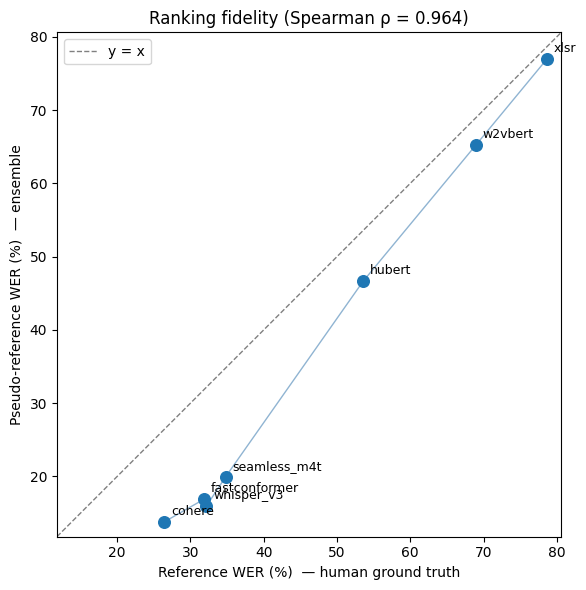

In [79]:
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

m = merged_B.copy().sort_values("wer_abs").reset_index(drop=True)
x = m["wer_abs"].values
y = m["wer_rel"].values
rho = spearmanr(x, y).statistic

fig, ax = plt.subplots(figsize=(6, 6))

# connector in reference-rank order (rises = ranking preserved, dip = inversion)
ax.plot(x, y, "-", color="steelblue", lw=1, alpha=0.6, zorder=2)
ax.scatter(x, y, s=70, zorder=3)

for _, r in m.iterrows():
    ax.annotate(r["model"], (r["wer_abs"], r["wer_rel"]),
                xytext=(5, 5), textcoords="offset points", fontsize=9)

lo = min(x.min(), y.min()) - 2
hi = max(x.max(), y.max()) + 2
ax.plot([lo, hi], [lo, hi], "--", color="gray", lw=1, zorder=1, label="y = x")

ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
ax.set_xlabel("Reference WER (%)  — human ground truth")
ax.set_ylabel("Pseudo-reference WER (%)  — ensemble")
ax.set_title(f"Ranking fidelity (Spearman ρ = {rho:.3f})")
ax.set_aspect("equal")
ax.legend()
fig.tight_layout()
plt.show()

In [12]:
df_full = pd.concat(filtered_full)
df_full_eval = evaluate_absolute_metrics(df_full)
df_full_eval[["model", "WER (%)", "CER (%)"]]

,model,WER (%),CER (%)
0,ensemble,24.66,11.68
1,cohere,25.34,13.36
2,fastconformer,30.96,14.26
3,rover,30.97,16.58
4,whisper_v3,31.11,13.87
5,seamless_m4t,33.28,16.91
6,hubert,52.00,21.90
7,wav2vec,68.58,27.90
8,xlsr,77.60,35.17


In [14]:
df_full_rel_rover = evaluate_relative_metrics(df_full, "rover", exclude_models=["ensemble", "hybrid_ensemble", "rover"])
df_full_rel_ensemble = evaluate_relative_metrics(df_full, "ensemble", exclude_models=["rover", "hybrid_ensemble", "ensemble"])
# df_full_rel_hybrid_ensemble = evaluate_relative_metrics(df_full, "hybrid_ensemble", exclude_models=["ensemble", "rover", "hybrid_ensemble"])

In [16]:
df_full_rel_ensemble[["model", "WER (%)", "CER (%)"]]

,model,WER (%),CER (%)
0,cohere,12.72,8.29
1,whisper_v3,14.97,7.17
2,fastconformer,15.84,7.97
3,seamless_m4t,18.95,10.86
4,whisper_v2,21.32,10.19
5,hubert,45.07,18.48
6,wav2vec,64.85,25.52
7,xlsr,75.92,33.72


In [72]:
df_full_rel_ensemble

,model,WER (%),w_substitutions,w_deletions,w_insertions,w_hits,word_edit_distance,word_similarity_ratio (%),w_ref_length,w_hyp_length,CER (%),c_substitutions,c_deletions,c_insertions,c_hits,char_edit_distance,char_similarity_ratio (%),c_ref_length,c_hyp_length
0,whisper_v3,15.02,3028,897,607,26244,4532,92.45,30169,29879,7.53,2551,4040,4750,143984,11341,96.24,150575,151285
1,fastconformer,15.62,3091,1017,603,26061,4711,92.14,30169,29755,7.94,2624,4758,4581,143193,11963,96.03,150575,150398
2,seamless_m4t,19.79,3442,1428,1101,25299,5971,90.05,30169,29842,11.43,3249,7486,6471,139840,17206,94.27,150575,149560
3,whisper_v2,22.55,4663,1006,1135,24500,6804,88.75,30169,30298,10.96,4048,4869,7588,141658,16505,94.57,150575,153294
4,hubert,43.58,9646,2412,1089,18111,13147,77.72,30169,28846,18.09,8219,11669,7349,130687,27237,90.82,150575,146255
5,wav2vec,64.24,14125,4612,645,11432,19382,65.62,30169,26202,25.44,10059,22316,5929,118200,38304,86.55,150575,134188
6,xlsr,75.52,17118,4845,821,8206,22784,59.54,30169,26145,33.54,18552,22161,9790,109862,50503,82.51,150575,138204
